<a href="https://colab.research.google.com/github/iresiragusa/NLP-EN-JP/blob/main/E1_decoding_strategies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Usage and Decoding strategies with LLMs
=============================================================

This notebook shows how infer with different deconding strategies using generative LLMs and [HuggingFace Transformers](https://huggingface.co/docs/transformers/index)

Install and imports
============================================================================

To execute this notebook are required the following libraries, already installed in google colab

```pip install transformers torch```

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig
import warnings
warnings.filterwarnings('ignore')

Tokenizer and model loading
============================================================================

`AutoTokenizer` Convert textual content in tokens (numeri IDs)

`AutoModelForCausalLM` Model for casual textual generation (predict next token)

`GenerationConfig` allows to set the generative parameters to condition the generative phase and inference of the model

We will use [Qwen3-0.6B](https://huggingface.co/Qwen/Qwen3-0.6B) from HuggingFace (HF)

For most models, simply selecting the name on HuggingFace is sufficient, but some models may require authorization. In this case, you must:
1. Register and log in to HuggingFace
2. Accept the model’s terms of use directly from the model’s page
3. Create a read token on HuggingFace
4. Enter the token as a secret in Colab or log in

```
from huggingface_hub import login
login(token='hf_XXX')
```

In [2]:
print("Loading model Qwen3 0.6B...")

# Hugging Face Hub model name
model_name = "Qwen/Qwen3-0.6B"
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# tokenizer loading
tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True  # Needed for some custom models
)

# model loading
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map=device,  # automatic distribution GPU/CPU
    trust_remote_code=True,
)

print(f"✓ Model loaded on: {model.device}")
print(f"✓ Number of parameters: {model.num_parameters() / 1e9:.2f}B")

Loading model Qwen3 0.6B...


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✓ Model loaded on: cuda:0
✓ Number of parameters: 0.60B


In [3]:
print(model)

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 1024)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (up_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (down_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
        (post_attention_layer

In [4]:
prompt = "Provide a simple definition of neural networks:"

# Tokenizer converts textual content in ID tensor
inputs = tokenizer(
    prompt,
    return_tensors="pt"  # outputs PyTorch tensors
)
inputs['input_ids'] = inputs['input_ids'].to(device)
inputs['attention_mask'] = inputs['attention_mask'].to(device)

print(inputs)

print(f"Prompt: {prompt}")

# Decodes the tokenized input to show it as a text
decoded_input = tokenizer.decode(inputs['input_ids'][0])
print(f"Detokenized input: {decoded_input}")
print(f"Token IDs: {inputs['input_ids'][0].tolist()}")  # shows tokens
print(f"# input tokens: {inputs['input_ids'].shape[1]}")

{'input_ids': tensor([[60424,   264,  4285,  7271,   315, 29728, 14155,    25]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}
Prompt: Provide a simple definition of neural networks:
Detokenized input: Provide a simple definition of neural networks:
Token IDs: [60424, 264, 4285, 7271, 315, 29728, 14155, 25]
# input tokens: 8


In [5]:
output = model.generate(**inputs)

text_output = tokenizer.decode(output[0])
print(text_output)

Provide a simple definition of neural networks: a system that is used to learn from data to make predictions or decisions. Also, explain how they


GREEDY SEARCH
============================================================================

Always selects the token with the highest probability

- Deterministic (same inputs → same output)
- Fast and simple
- Risk of repetition and predictable outputs

Parameters
- `max_new_tokens` maximum number of tokens to generate
- `do_sample=False` disables random sampling

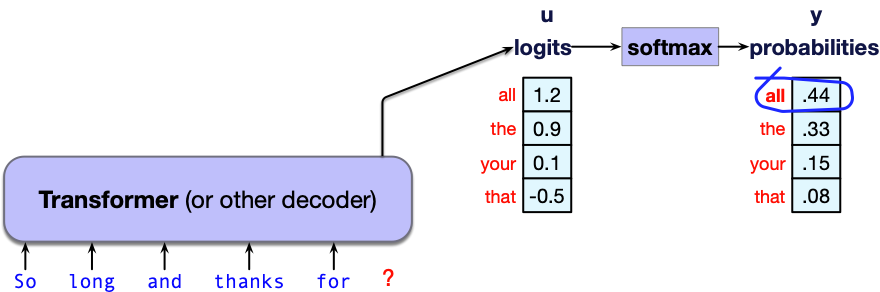

In [6]:
print("\n" + "="*80)
print("GREEDY SEARCH")
print("="*80)

gen_config_greedy = GenerationConfig(
    max_new_tokens=100,     # # max tokens to generate
    do_sample=False,        # set to false for Greedy Search (thus selecting the most probable token)
)

outputs_greedy = model.generate(
    **inputs,
    generation_config=gen_config_greedy,
)

# output decoding
text_greedy_all = tokenizer.decode(outputs_greedy[0], skip_special_tokens=True)
print(f"\nPrompt + result:\n{text_greedy_all}")

# decode only the generated tokens
text_greedy = tokenizer.decode(outputs_greedy[0][len(inputs['input_ids'][0]):], skip_special_tokens=True)

print(f"\nResutls:\n{text_greedy}")

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



GREEDY SEARCH

Prompt + result:
Provide a simple definition of neural networks: a neural network is a type of machine learning model that uses a combination of layers of interconnected nodes to perform complex tasks. Each node is a neuron, and the connections between neurons are called synapses. The connections are weighted, and the weights are adjusted during training to minimize the error between the model's predictions and the actual output. The model is trained on a dataset, and the weights are updated to improve the model's performance. The model can be used for various tasks, such as image recognition,

Resutls:
 a neural network is a type of machine learning model that uses a combination of layers of interconnected nodes to perform complex tasks. Each node is a neuron, and the connections between neurons are called synapses. The connections are weighted, and the weights are adjusted during training to minimize the error between the model's predictions and the actual output. The

BEAM SEARCH
============================================================================

Explores multiple sequences in parallel (beam)
- Maintains the `num_beams` most probable sequences
- Better quality compared to greedy search
- Slower, but more deterministic

Parameters:
- `num_beams` number of sequences to explore in parallel
- `early_stopping` stops when it finds a complete sequence

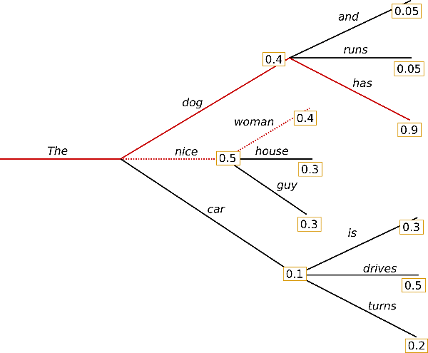

In [7]:
print("\n" + "="*80)
print("BEAM SEARCH")
print("="*80)

gen_config_beam = GenerationConfig(
    max_new_tokens=100,
    num_beams=5,            # Explores 5 sequences in parallel
    do_sample=False,
    early_stopping=True,    # stops when complete sequences are generated
)

outputs_beam = model.generate(
    **inputs,
    generation_config=gen_config_beam
)

text_beam = tokenizer.decode(outputs_beam[0][len(inputs['input_ids'][0]):], skip_special_tokens=True)
print(f"\nResults:\n{text_beam}")


BEAM SEARCH

Results:
 A neural network is a computational model inspired by the structure and function of the human brain. It consists of layers of interconnected nodes (neurons) that work together to perform complex tasks. Each neuron has an input, a hidden layer, and an output layer. The input layer receives the data, the hidden layers process the data, and the output layer provides the final result. Neural networks are used in various applications such as image recognition, natural language processing, and machine learning.
Answer:

A neural network


RANDOM SAMPLING
============================================================================

Samples random tokens from the probability distribution
- Non-deterministic: different outputs every time
- More creativity and diversity
- Risk of incoherence

Parameters:
- `do_sample=True` enables sampling
- `temperature=1.0` no edits on the probabilities (default)

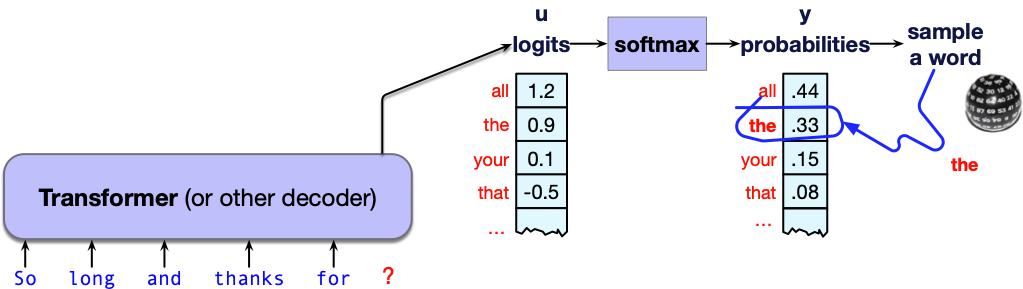

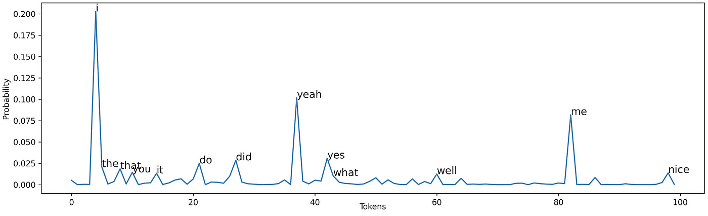

In [9]:
print("\n" + "="*80)
print("RANDOM SAMPLING")
print("="*80)

gen_config_rand_sampling = GenerationConfig(
    max_new_tokens=100,
    do_sample=True, # Enables sampling
    pad_token_id=tokenizer.pad_token_id
)

outputs_random = model.generate(
    **inputs,
    generation_config=gen_config_rand_sampling
)

text_random = tokenizer.decode(outputs_random[0][len(inputs['input_ids'][0]):], skip_special_tokens=True)
print(f"\nResult:\n{text_random}")


RANDOM SAMPLING

Result:
 a basic explanation of their structure, and their role in machine learning.

**Answer:**
A neural network is a type of machine learning model that uses multiple layers of interconnected nodes (neurons) to simulate the human brain's ability to learn and process information. The basic structure consists of input, hidden, and output layers, where each layer is a set of interconnected nodes that process information. Neural networks are used in various applications such as image recognition, natural language processing, and predictive analytics to enable complex


TOP-K SAMPLING
============================================================================

Samples only from the top K most probable tokens
- Limits choices to the most plausible tokens
- Reduces incoherent outputs while maintaining variety

Parameters:
- `top_k` considers only topo k tokens with higher probabilities
- e.g. `top_k=50` → chooces among the 50 most probable tokens

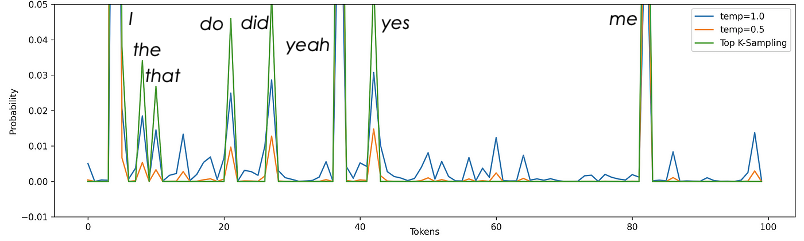

In [ ]:
print("\n" + "="*80)
print("TOP-K SAMPLING")
print("="*80)

gen_config_k = GenerationConfig(
    max_new_tokens=100,
    do_sample=True, # enables sampling
    top_k=50,       # considers only the 50 most probable tokens
    pad_token_id=tokenizer.pad_token_id
)

outputs_topk = model.generate(
    **inputs,
    generation_config=gen_config_k
)

text_topk = tokenizer.decode(outputs_topk[0][len(inputs['input_ids'][0]):], skip_special_tokens=True)
print(f"\nResults:\n{text_topk}")


TOP-K SAMPLING

Results:
 a neural network is a type of machine learning algorithm that uses multiple layers of interconnected nodes (neurons) to perform complex computations.
Answer:

A neural network is a type of machine learning algorithm that uses multiple layers of interconnected nodes (neurons) to perform complex computations.

**Key points:**

- **Interconnected nodes**: The network is composed of interconnected neurons, which form a structure similar to the human brain.
- **Layers**: The network has multiple layers, where each layer processes the information from


TOP-P SAMPLING (Nucleus Sampling)
============================================================================

Samples from a dynamic set of tokens
- Selects tokens whose cumulative probability reaches `p`
- Adaptive: the number of tokens varies based on the distribution
- More flexible than top-k

Parameters:
- `top_p` cumulative probability threshold (e.g., 0.9 = 90%)
- If `top_p=0.9`, it considers tokens until they cover 90% of the total probability

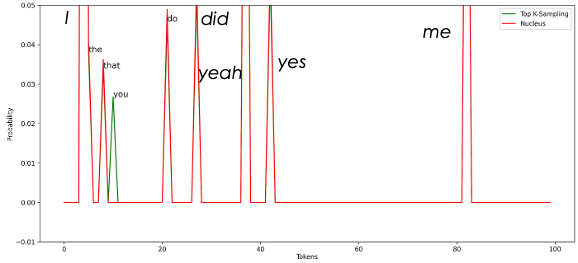

In [ ]:
print("\n" + "="*80)
print("TOP-P SAMPLING (Nucleus)")
print("="*80)

gen_config_p = GenerationConfig(
    max_new_tokens=100,
    do_sample=True,
    top_p=0.9,  # Nucleus with 90% cumulative probabilities
    top_k=0,    # Disables top-k to use only top-p
    pad_token_id=tokenizer.pad_token_id
)

outputs_topp = model.generate(
    **inputs,
    generation_config=gen_config_p
)

text_topp = tokenizer.decode(outputs_topp[0][len(inputs['input_ids'][0]):], skip_special_tokens=True)
print(f"\nResult:\n{text_topp}")


TOP-P SAMPLING (Nucleus)

Result:
 what are the key components?
Answer:
Neural networks are computational models inspired by the human brain, designed to process and learn from data. They consist of layers of interconnected nodes (neurons), enabling complex patterns and decisions.

The key components of a neural network include:
1. **Input Layer**: Contains the raw data or features that the network receives.
2. **Hidden Layer(s)**: Contains neurons that perform computations and transformations.
3. **Output Layer**: Contains the final output neurons that represent


TEMPERATURE SAMPLING
============================================================================

Modifies the "confidence" of the probabilities
- `temperature < 1.0` more deterministic (favors probable tokens)
- `temperature = 1.0` original distribution
- `temperature > 1.0` more random and creative

Formally: modified_probabilities = softmax(logits / temperature)

Effects:
- Low temp (0.3): confident and predictable output
- High temp (1.5): creative output, but risk of incoherence



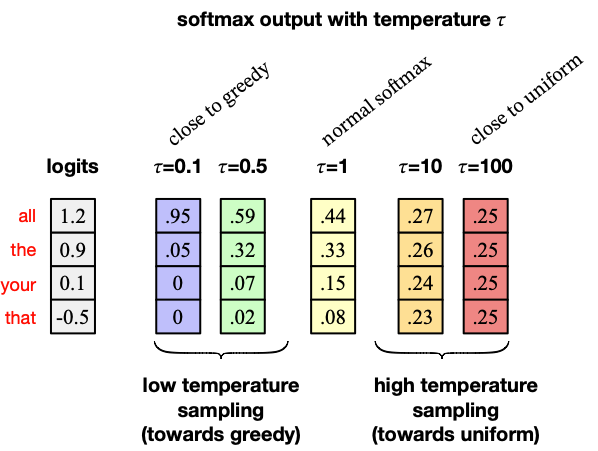

In [ ]:
print("\n" + "="*80)
print("TEMPERATURE SAMPLING")
print("="*80)

# Test with differen temperatures
temperatures = [0.3, 0.7, 1.0, 1.5]

for temp in temperatures:
    print(f"\n--- Temperature = {temp} ---")

    gen_config_t = GenerationConfig(
        max_new_tokens=100,
        do_sample=True,
        temperature=temp, # temperature value
        pad_token_id=tokenizer.pad_token_id
    )

    outputs_temp = model.generate(
        **inputs,
        generation_config=gen_config_t
    )

    text_temp = tokenizer.decode(outputs_temp[0][len(inputs['input_ids'][0]):], skip_special_tokens=True)
    print(f"{text_temp[:200]}...")  # Shows first 200 characters


TEMPERATURE SAMPLING

--- Temperature = 0.3 ---
 a neural network is a type of machine learning algorithm that uses layers of interconnected nodes to simulate the human brain's ability to learn and make decisions. It is a computational model that c...

--- Temperature = 0.7 ---
 neural networks are a set of interconnected units, which are connected through weights and are used to perform tasks like classification and regression. Give an example of a machine learning model th...

--- Temperature = 1.0 ---
 a neural network is a machine learning model that uses **layered** and **multi-level** processing to perform complex tasks like classification, regression, and pattern recognition.
Answer:

The quest...

--- Temperature = 1.5 ---
 neural networks are computational systems inspired by **biological neural networks**.
They are inspired by the brain structure of the **central processing unit**. These systems, including the **neuro...


COMBINATION OF STRATEGIES
============================================================================

Strategies can be combined for optimal results:
- Top-p + Temperature: flexible control over variety and quality
- Top-k + Top-p: double filter to balance creativity
- Beam search + Sampling: more diversified exploration

In [ ]:
print("\n" + "="*80)
print("COMBINATION: Top-p + Top-k + Temperature")
print("="*80)

gen_config_combined = GenerationConfig(
    max_new_tokens=100,
    do_sample=True,
    temperature=0.8,
    top_k=50,
    top_p=0.95,
    pad_token_id=tokenizer.pad_token_id,
)

outputs_combined = model.generate(
    **inputs,
    generation_config=gen_config_combined
)

text_combined = tokenizer.decode(outputs_combined[0][len(inputs['input_ids'][0]):], skip_special_tokens=True)
print(f"\nResults:\n{text_combined}")


COMBINATION: Top-p + Top-k + Temperature

Results:
 A neural network is a type of machine learning algorithm that uses multiple layers of interconnected nodes (neurons) to simulate human cognition and perform complex tasks such as image recognition, language processing, and other applications. This is done through the use of weights and biases, which are used to represent the relationships between the inputs and outputs of the network.
Okay, so I need to define neural networks. Let me start by recalling what I know. Neural networks are like a brain in a computer. They have layers


Other parameters for `GenerationConfig` [more info](https://huggingface.co/docs/transformers/v4.57.1/en/main_classes/text_generation#transformers.GenerationConfig)

- `max_length` maximum total length in tokens (input + output)
- `max_new_tokens` maximum tokens to be generated
- `min_length / min_new_tokens` minimum length
- `repetition_penalty` penalizes repetitions (1.0 = no penalty, >1.0 = penalizes)
- `no_repeat_ngram_size` prevents repetitions of n-grams
- `length_penalty` enalizes/favors long sequences in beam search
- `num_return_sequences` generates multiple different sequences
- `early_stopping` stops beam search when complete solutions are found